<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-11/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 11 — Capstone: an end-to-end ML project

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

This capstone stitches the whole course into one reproducible workflow on real
climate data. You will practice the full cycle a data scientist runs:

> **question → data → features → model → evaluation → interpretation**

## The brief
> *Build and validate a model that predicts whether it will rain in Maceió, and
> use the global climate datasets to put that local weather in a warming-world
> context.*

Datasets: [Maceió daily weather](../../datasets/maceio_daily_weather.DATASET.md),
[GISTEMP](../../datasets/gistemp_global_annual.DATASET.md),
[Mauna Loa CO₂](../../datasets/maunaloa_co2_annual.DATASET.md).

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


In [2]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

wx = load_dataset("maceio_daily_weather.csv")
temp = load_dataset("gistemp_global_annual.csv")
co2 = load_dataset("maunaloa_co2_annual.csv")

## Step 1 — Feature engineering

We engineer a couple of seasonal features so the model can exploit the annual
cycle (Maceió's rainy season peaks around May–July).

In [3]:
d = wx.copy()
d["season_sin"] = np.sin(2 * np.pi * d["month"] / 12)
d["season_cos"] = np.cos(2 * np.pi * d["month"] / 12)

features = ["temp_max_c", "temp_min_c", "temp_mean_c", "humidity_pct",
            "pressure_hpa", "wind_max_kmh", "solar_rad_mj_m2",
            "season_sin", "season_cos"]
X = d[features].values
y = d["rained"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)

## Step 2 — Train and cross-validate a model

In [4]:
clf = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1)
cv = cross_val_score(clf, X, y, cv=5, scoring="f1")
print(f"5-fold F1 = {cv.mean():.3f} ± {cv.std():.3f}")

clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
print(f"held-out ROC AUC = {roc_auc_score(y_te, proba):.3f}\n")
print(classification_report(y_te, clf.predict(X_te), target_names=["no rain", "rain"]))

5-fold F1 = 0.860 ± 0.032


held-out ROC AUC = 0.893

              precision    recall  f1-score   support

     no rain       0.73      0.70      0.72       434
        rain       0.86      0.88      0.87       936

    accuracy                           0.82      1370
   macro avg       0.80      0.79      0.79      1370
weighted avg       0.82      0.82      0.82      1370



## Step 3 — Interpret the model

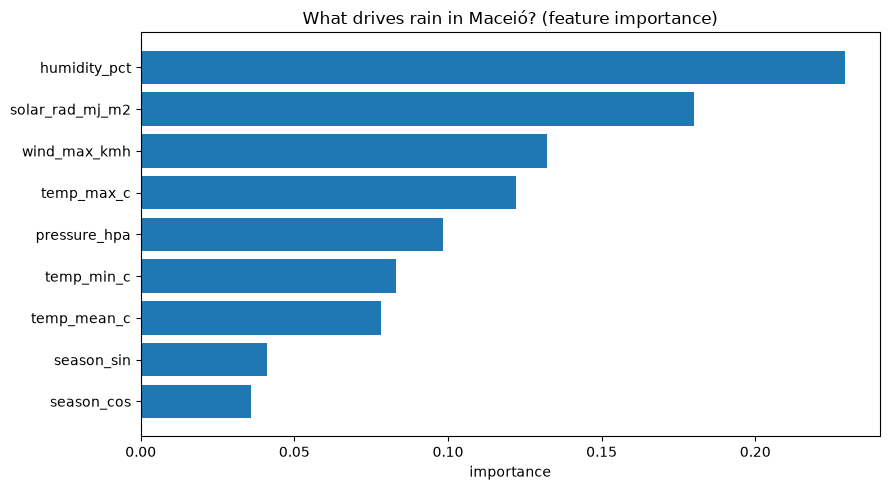

In [5]:
imp = sorted(zip(features, clf.feature_importances_), key=lambda t: t[1])
plt.barh([n for n, _ in imp], [v for _, v in imp])
plt.title("What drives rain in Maceió? (feature importance)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

## Step 4 — The bigger picture: a warming world

The local model lives inside a global trend. Here we connect the two background
datasets: rising CO₂ and rising temperature over the period our weather record
covers.

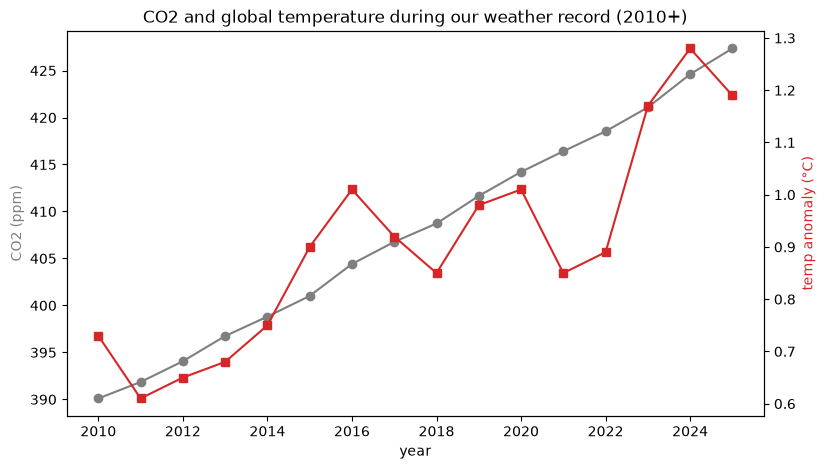

In [6]:
m = co2.merge(temp, on="year")
m = m[m["year"] >= 2010]
fig, ax1 = plt.subplots()
ax1.plot(m["year"], m["co2_ppm"], color="tab:gray", marker="o", label="CO2")
ax1.set_xlabel("year"); ax1.set_ylabel("CO2 (ppm)", color="tab:gray")
ax2 = ax1.twinx()
ax2.plot(m["year"], m["temp_anomaly_c"], color="tab:red", marker="s", label="temp anomaly")
ax2.set_ylabel("temp anomaly (°C)", color="tab:red")
plt.title("CO2 and global temperature during our weather record (2010+)")
plt.show()

## Step 5 — Write up your findings

A project is only finished when it is **communicated**. In 4–6 sentences, answer:

- How well does the model predict rain, and which features matter most?
- What are its **limitations** (data leakage risks, imbalance, single location)?
- How would you deploy or improve it?

## Open-ended extensions (pick one)
1. **Forecasting:** combine with lecture 08 to predict *tomorrow's* rain
   probability from today's conditions (lag features).
2. **Transfer:** pull another city from the Open-Meteo API (see
   `scripts/fetch_data.py`) and test whether a model trained on Maceió generalizes.
3. **Imbalance:** apply class weighting or resampling and measure the effect on
   the *no-rain* recall.
4. **Explainability:** use permutation importance or partial-dependence plots to
   go beyond impurity-based importance.

## Reproducibility checklist
- [ ] Notebook runs top-to-bottom with no manual steps
- [ ] Data loaded from the versioned `datasets/` catalog (or its source URLs)
- [ ] Random seeds fixed; metrics reported with the evaluation protocol stated
- [ ] Environment captured in `requirements.txt` / `environment.yml`